<a href="https://colab.research.google.com/github/yuvipaloozie/CHANA/blob/main/notebooks/CHANA_Inference_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q tqdm keras-unet-collection
!pip install keras-unet-collection
import os
os.environ["SM_FRAMEWORK"] = "tf.keras"
import numpy as np
import cv2
import tensorflow as tf
from keras_unet_collection import models as unet_models

# --- CONFIGURATION (Matches Winning Script) ---
PROJECT_BASE_PATH = '/content/drive/MyDrive/CHANA_files'
WEIGHTS_PATH = os.path.join(PROJECT_BASE_PATH, 'CHANA Final Models and Programs/model_weights/Unetplusplus_no_Domain.weights.h5')
IMG_SIZE = 512
NUM_CLASSES = 1

def build_verified_unetplusplus(input_shape=(512, 512, 3), num_classes=1):
    """
    Rebuilds the winning U-Net++ ResNet50 architecture.
    Parameters verified against chana_unet++_with_domains.py
    """
    print(f"🏗️ Rebuilding U-Net++ (ResNet50) Architecture...")
    return unet_models.unet_plus_2d(
        input_size=input_shape,
        filter_num=[64, 128, 256, 512],
        n_labels=num_classes,
        stack_num_down=4,
        stack_num_up=4,
        activation='ReLU',          # Verified: Matches winning script
        output_activation='Sigmoid',# Verified: Matches winning script
        batch_norm=True,
        pool=False, unpool=False,
        backbone='ResNet50',
        weights='imagenet',
        freeze_backbone=False,
        deep_supervision=True       # Verified: Necessary for 4-output heads
    )

# Initialize Model
model = build_verified_unetplusplus()

# Load Weights
if os.path.exists(WEIGHTS_PATH):
    model.load_weights(WEIGHTS_PATH)
    print(f"✅ CHANA Weights Loaded Successfully: {os.path.basename(WEIGHTS_PATH)}")
    print(f"   -> Deep Supervision Heads Detected: {len(model.outputs)}")
else:
    print(f"❌ ERROR: Weights not found at {WEIGHTS_PATH}")

🏗️ Rebuilding U-Net++ (ResNet50) Architecture...
----------
deep_supervision = True
names of output tensors are listed as follows ("sup0" is the shallowest supervision layer;
"final" is the final output layer):

	xnet_output_sup0_activation
	xnet_output_sup1_activation
	xnet_output_final_activation
✅ CHANA Weights Loaded Successfully: Unetplusplus_no_Domain.weights.h5
   -> Deep Supervision Heads Detected: 3


In [ ]:
import time
from tqdm.auto import tqdm
from scipy import ndimage
from skimage import measure
from skimage.feature import peak_local_max
from skimage.segmentation import watershed

# Constants from training
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def preprocess_v9(img_bgr):
    """V9 'Nuclear Pop' + Model Normalization."""
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_clahe = clahe.apply(l)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    nuclei_map = cv2.morphologyEx(l_clahe, cv2.MORPH_TOPHAT, kernel)
    l_final = cv2.addWeighted(l_clahe, 1.0, nuclei_map, 0.8, 0)
    img_enhanced = cv2.cvtColor(cv2.merge((l_final, a, b)), cv2.COLOR_LAB2RGB)
    img_norm = img_enhanced.astype(np.float32) / 255.0
    return (img_norm - IMAGENET_MEAN) / IMAGENET_STD

def run_verbose_pipeline(image_path, model):
    """Loads, Tiles, Processes, and Stitches with real-time feedback."""
    print(f"📁 Loading: {os.path.basename(image_path)}")
    raw_bgr = cv2.imread(image_path)
    h, w, _ = raw_bgr.shape
    print(f"   -> Resolution: {w}x{h} ({(w*h)/1e6:.1f} MP)")

    pad_h = (IMG_SIZE - h % IMG_SIZE) % IMG_SIZE
    pad_w = (IMG_SIZE - w % IMG_SIZE) % IMG_SIZE
    padded = cv2.copyMakeBorder(raw_bgr, 0, pad_h, 0, pad_w, cv2.BORDER_CONSTANT, value=[255,255,255])

    stitched_prob = np.zeros((padded.shape[0], padded.shape[1]), dtype=np.float32)
    y_steps, x_steps = range(0, padded.shape[0], IMG_SIZE), range(0, padded.shape[1], IMG_SIZE)
    total_tiles = len(y_steps) * len(x_steps)

    print(f"🧱 Tiling: {total_tiles} patches | 🧠 Inference: Sequential Mode")
    inf_start = time.time()

    with tqdm(total=total_tiles, desc="Processing Tiles", unit="tile") as pbar:
        for y in y_steps:
            for x in x_steps:
                patch = padded[y:y+IMG_SIZE, x:x+IMG_SIZE]
                patch_norm = preprocess_v9(patch)
                preds = model.predict(np.expand_dims(patch_norm, 0), verbose=0)
                stitched_prob[y:y+IMG_SIZE, x:x+IMG_SIZE] = preds[-1][0, :, :, 0]
                pbar.update(1)

    print(f"✅ Inference Complete ({time.time() - inf_start:.2f}s)")
    return raw_bgr, stitched_prob[:h, :w]

def get_verbose_count(prob_map, min_area=50, min_dist=20):
    print("🔬 Extracting Biological Objects (Watershed Enabled)...")
    post_start = time.time()

    # 1. Threshold and Fill Holes
    mask = (prob_map > 0.5).astype(np.uint8)
    mask = ndimage.binary_fill_holes(mask).astype(np.uint8)

    # 2. Distance Transform & Peak Detection
    distance = ndimage.distance_transform_edt(mask)
    local_maxi = peak_local_max(distance, min_distance=min_dist, labels=mask)

    # 3. Watershed Separation
    if len(local_maxi) > 0:
        markers_mask = np.zeros(distance.shape, dtype=bool)
        markers_mask[tuple(local_maxi.T)] = True
        markers, _ = ndimage.label(markers_mask)
        labels = watershed(-distance, markers, mask=mask)
    else:
        labels = measure.label(mask)

    # ... (previous watershed logic remains the same) ...

    # 4. Area Filtering & Feature Extraction
    props = [r for r in measure.regionprops(labels) if r.area > min_area]

    centroids = [r.centroid for r in props]
    areas = [r.area for r in props] # Extract pixel area for each cell

    print(f"✅ Finished in {time.time() - post_start:.2f}s.")
    return mask, len(props), centroids, areas

📁 Loading: P1_R75_Exenatide25_B6.tif
   -> Resolution: 8056x7480 (60.3 MP)
🧱 Tiling: 240 patches | 🧠 Inference: Sequential Mode


Processing Tiles:   0%|          | 0/240 [00:00<?, ?tile/s]

✅ Inference Complete (31.99s)
🔬 Extracting Biological Objects (Watershed Enabled)...
✅ Finished in 17.69s.


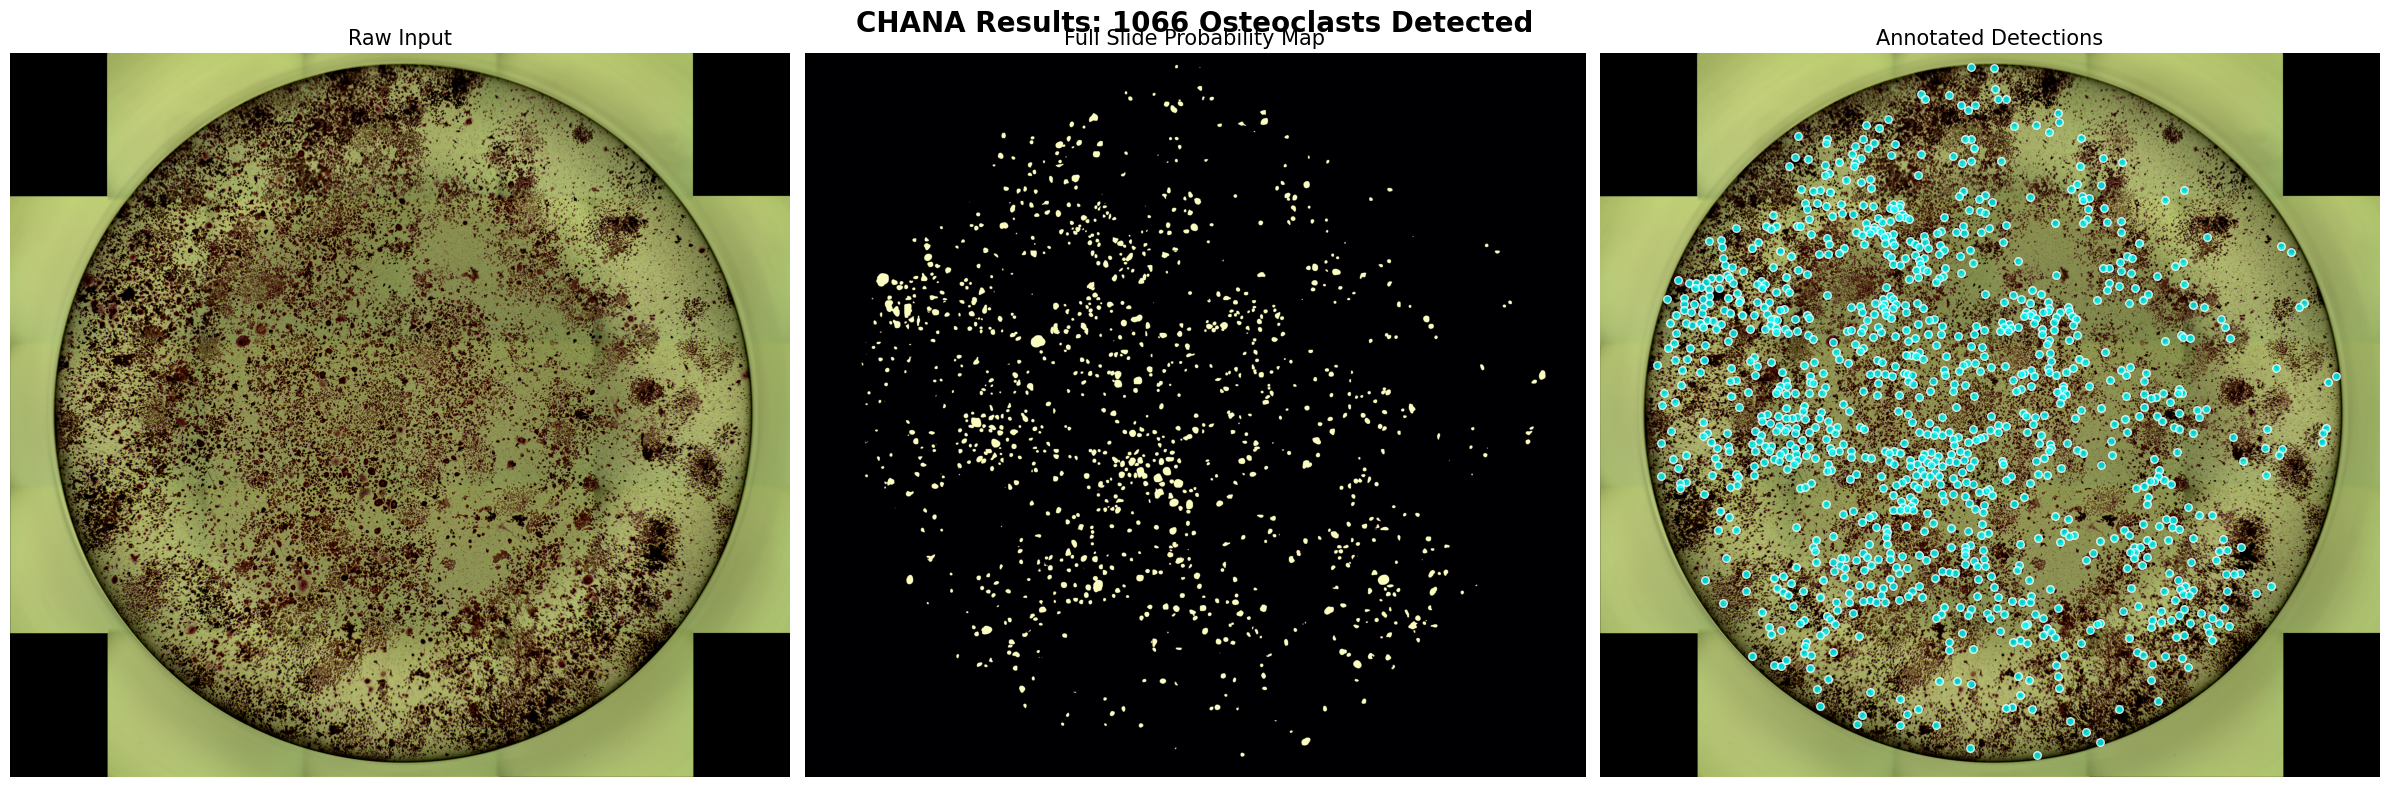

In [ ]:
# --- RUN THIS TO TEST ON AN 8K IMAGE ---
import matplotlib.pyplot as plt
TEST_IMAGE_PATH = os.path.join(PROJECT_BASE_PATH, 'tiling images', 'P1_R75_Exenatide25_B6.tif')

if os.path.exists(TEST_IMAGE_PATH):
    # 1. Execute Verbose Pipeline
    # 1. Execute Verbose Pipeline
    raw_img, prob_map = run_verbose_pipeline(TEST_IMAGE_PATH, model)

    # 2. Get Count (Now catching the areas list!)
    final_mask, cell_count, centroids, areas = get_verbose_count(prob_map)

    # 3. Visualization
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    fig.suptitle(f"CHANA Results: {cell_count} Osteoclasts Detected", fontsize=20, fontweight='bold')

    axes[0].imshow(cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Raw Input", fontsize=15)

    axes[1].imshow(prob_map, cmap='magma')
    axes[1].set_title("Full Slide Probability Map", fontsize=15)

    axes[2].imshow(cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB))

    if centroids:
      c_arr = np.array(centroids)
      axes[2].scatter(c_arr[:, 1], c_arr[:, 0], c='cyan', s=30, edgecolors='white', alpha=0.8)

    axes[2].set_title("Annotated Detections", fontsize=15)

    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("❌ Path invalid. Ensure the filename matches your Drive exactly.")

In [ ]:
# ==============================================================================
# CELL 4: THE AUDIT GALLERY (Tiled Validation Export)
# ==============================================================================
def export_audit_gallery(raw_bgr, prob_map, centroids, output_folder, alpha=0.2):
    """
    Slices the slide into tiles and only saves the ones containing
    detected osteoclasts for rapid manual verification.
    """
    h, w, _ = raw_bgr.shape
    slide_name = "Slide_Audit"
    gallery_path = os.path.join(output_folder, slide_name)
    os.makedirs(gallery_path, exist_ok=True)

    print(f"📦 Creating Audit Gallery in: {gallery_path}")

    # 1. Prepare global heatmap
    prob_uint8 = (prob_map * 255).astype(np.uint8)
    heatmap = cv2.applyColorMap(prob_uint8, cv2.COLORMAP_HOT)
    overlay_full = cv2.addWeighted(raw_bgr, 1 - alpha, heatmap, alpha, 0)

    # 2. Iterate through tiles
    saved_count = 0
    for y in range(0, h, IMG_SIZE):
        for x in range(0, w, IMG_SIZE):
            # Define tile boundaries
            y_end, x_end = min(y + IMG_SIZE, h), min(x + IMG_SIZE, w)

            # Check if any centroids fall within this specific tile
            tile_centroids = [c for c in centroids if y <= c[0] < y_end and x <= c[1] < x_end]

            if len(tile_centroids) > 0:
                # Extract tile from the global overlay
                tile = overlay_full[y:y_end, x:x_end].copy()

                # Save the "Hit" tile
                tile_fname = f"tile_y{y}_x{x}_count{len(tile_centroids)}.png"
                cv2.imwrite(os.path.join(gallery_path, tile_fname), tile)
                saved_count += 1

    print(f"✅ Audit Gallery Complete. Saved {saved_count} tiles containing cells.")

# --- EXECUTE ---
GALLERY_OUT = os.path.join(PROJECT_BASE_PATH, 'audit_galleries')
export_audit_gallery(raw_img, prob_map, centroids, GALLERY_OUT)

📦 Creating Audit Gallery in: /content/drive/MyDrive/CHANA_files/audit_galleries/Slide_Audit
✅ Audit Gallery Complete. Saved 145 tiles containing cells.


📊 Calculating size metrics for 1066 cells...


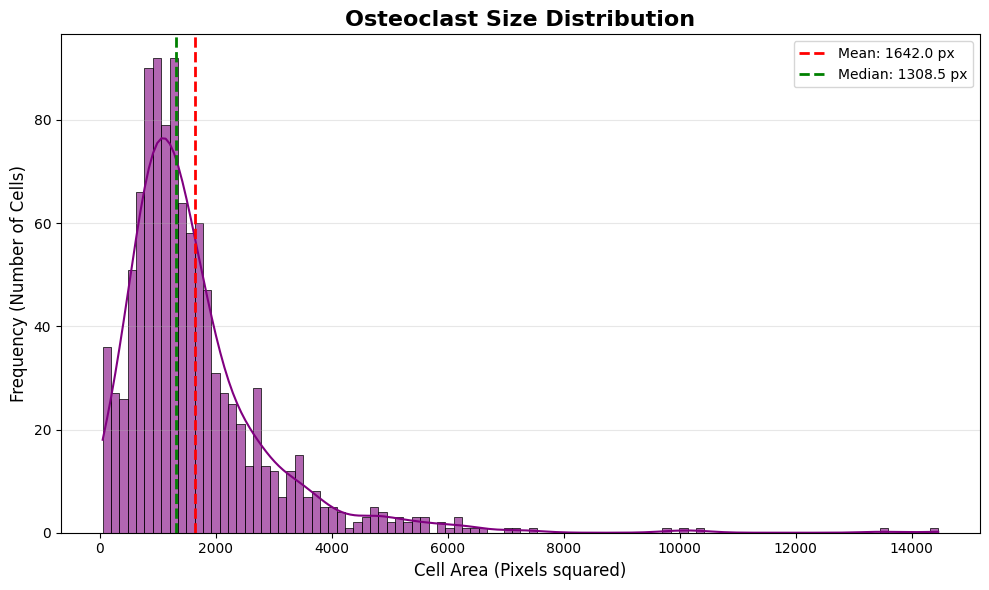

In [ ]:
# ==============================================================================
# CELL 5: OSTEOCLAST SIZE DISTRIBUTION (HISTOGRAM)
# ==============================================================================
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

def plot_area_distribution(areas_list, title="Osteoclast Size Distribution"):
    if not areas_list:
        print("No cells detected to plot.")
        return

    print(f"📊 Calculating size metrics for {len(areas_list)} cells...")

    # Convert to DataFrame for easier plotting
    df = pd.DataFrame({'Pixel Area': areas_list})

    plt.figure(figsize=(10, 6))

    # Plot histogram with a KDE (Kernel Density Estimate) curve overlay
    sns.histplot(data=df, x='Pixel Area', bins=100, kde=True, color='purple', alpha=0.6)

    # Calculate and plot mean and median lines
    mean_area = df['Pixel Area'].mean()
    median_area = df['Pixel Area'].median()

    plt.axvline(mean_area, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_area:.1f} px')
    plt.axvline(median_area, color='green', linestyle='dashed', linewidth=2, label=f'Median: {median_area:.1f} px')

    # Formatting
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel('Cell Area (Pixels squared)', fontsize=12)
    plt.ylabel('Frequency (Number of Cells)', fontsize=12)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

# Run the plotting function using the 'areas' list we unpacked earlier
plot_area_distribution(areas)